# Laboratorio 3 - Clasificación: SmartAlpes
## Paso 1: Exploración de los datos

En esta sección se realiza un análisis exploratorio del conjunto de datos de SmartAlpes con el fin de identificar problemas de calidad y características relevantes antes de proceder con el modelado.

### 1. Importación de librerías y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Cargar el conjunto de datos de entrenamiento
df = pd.read_csv('Datos_Laboratorio3.csv', sep=';', encoding='latin-1')

# Renombrar columnas con problemas de codificación o errores tipográficos
df.rename(columns={
    'Gnereo': 'Genero',
    'Horas_sue\xf1o': 'Horas_sueno',
    'Plan_nutrici\xf3n': 'Plan_nutricion'
}, inplace=True)

print("Columnas del dataset:")
print(df.columns.tolist())
df.head()

Columnas del dataset:
['Edad', 'Genero', 'Peso', 'Altura', 'BMI', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad', 'Nivel_experiencia', 'Dieta_preferida', 'Horas_sueno', 'Entrenamiento_preferido', 'Cantidad_equipo', 'Tiempo_disponible', 'Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Cigarrillos_dia', 'Alcohol', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua', 'Plan_entrenamiento', 'Plan_nutricion']


,Edad,Genero,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,...,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutricion
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,...,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,...,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,110.0,1.52,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.34,104.9,3050,2.53,Bajo,Basico
3,49,Otro,73.6,1.96,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,...,0,0.0,0,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan
4,53,Femenino,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,...,1,8.7,0,0.0,0.98,51.1,12774,1.90,Medio,Sin plan


### 2. Inspección inicial del conjunto de datos

In [2]:
print(f"Dimensiones del dataset: {df.shape[0]} filas, {df.shape[1]} columnas\n")

# Información general (tipos y no-nulos)
df.info()

Dimensiones del dataset: 9698 filas, 26 columnas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9698 entries, 0 to 9697
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Edad                     9698 non-null   int64  
 1   Genero                   9698 non-null   object 
 2   Peso                     9687 non-null   float64
 3   Altura                   9698 non-null   float64
 4   BMI                      9698 non-null   float64
 5   Objetivo                 9698 non-null   object 
 6   Condicion_salud          9698 non-null   object 
 7   Nivel_Actividad          9698 non-null   object 
 8   Nivel_experiencia        9698 non-null   object 
 9   Dieta_preferida          9698 non-null   object 
 10  Horas_sueno              9698 non-null   float64
 11  Entrenamiento_preferido  9698 non-null   object 
 12  Cantidad_equipo          9698 non-null   int64  
 13  Tiempo_disponible        969

In [3]:
# Estadísticas descriptivas para variables numéricas
print("Estadísticas descriptivas - Variables numéricas:")
df.describe().round(2)

Estadísticas descriptivas - Variables numéricas:


,Edad,Peso,Altura,BMI,Horas_sueno,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua
count,9698.00,9687.00,9698.00,9698.00,9698.00,9698.00,9698.00,9698.0,9698.00,9698.00,9698.00,9698.00,9698.00,9698.00,9698.00,9698.00,9698.00
mean,45.11,92.62,1.78,30.13,7.00,2.99,67.19,0.2,0.15,0.23,2.17,0.29,3.78,0.50,130.00,9765.94,2.75
std,17.64,27.38,0.16,10.61,1.45,2.02,30.84,0.4,0.36,0.42,4.62,0.45,7.02,0.29,51.98,4762.15,1.02
min,15.00,45.00,1.50,10.93,0.00,0.00,15.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,40.00,200.00,1.00
25%,30.00,68.80,1.64,21.62,5.80,1.00,40.00,0.0,0.00,0.00,0.00,0.00,0.00,0.25,85.00,5608.25,1.86
50%,45.00,92.60,1.78,29.19,7.00,3.00,67.00,0.0,0.00,0.00,0.00,0.00,0.00,0.50,129.95,9718.00,2.76
75%,61.00,116.50,1.91,37.06,8.20,5.00,94.00,0.0,0.00,0.00,0.00,1.00,4.30,0.75,175.20,13953.00,3.62
max,75.00,140.00,2.05,62.09,23.00,6.00,120.00,1.0,1.00,1.00,18.00,1.00,25.00,1.00,220.00,17996.00,4.50


In [4]:
# Identificar columnas numéricas y categóricas
cols_numericas = df.select_dtypes(include=['number']).columns.tolist()
cols_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("Variables numéricas:")
print(cols_numericas)
print(f"\nVariables categóricas:")
print(cols_categoricas)

Variables numéricas:
['Edad', 'Peso', 'Altura', 'BMI', 'Horas_sueno', 'Cantidad_equipo', 'Tiempo_disponible', 'Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Cigarrillos_dia', 'Alcohol', 'Alcohol_semana', 'Score_micronutrientes', 'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua']

Variables categóricas:
['Genero', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad', 'Nivel_experiencia', 'Dieta_preferida', 'Entrenamiento_preferido', 'Plan_entrenamiento', 'Plan_nutricion']


### 3. Análisis de valores faltantes

Columnas con valores faltantes:


,Valores faltantes,Porcentaje (%)
Peso,11,0.11


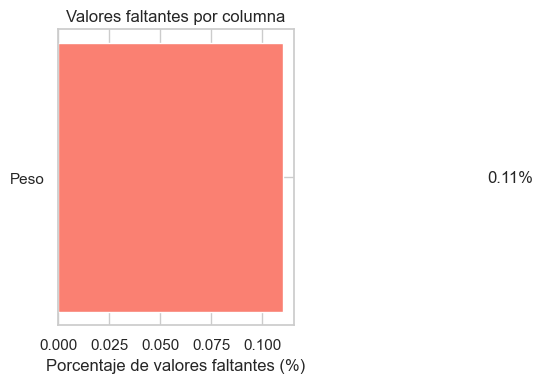

In [5]:
# Conteo y porcentaje de valores faltantes por columna
missing = pd.DataFrame({
    'Valores faltantes': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Valores faltantes'] > 0].sort_values('Porcentaje (%)', ascending=False)

print("Columnas con valores faltantes:")
display(missing)

# Visualización de valores faltantes
if not missing.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(missing.index, missing['Porcentaje (%)'], color='salmon')
    ax.set_xlabel('Porcentaje de valores faltantes (%)')
    ax.set_title('Valores faltantes por columna')
    for i, v in enumerate(missing['Porcentaje (%)']):
        ax.text(v + 0.1, i, f'{v:.2f}%', va='center')
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron valores faltantes.")

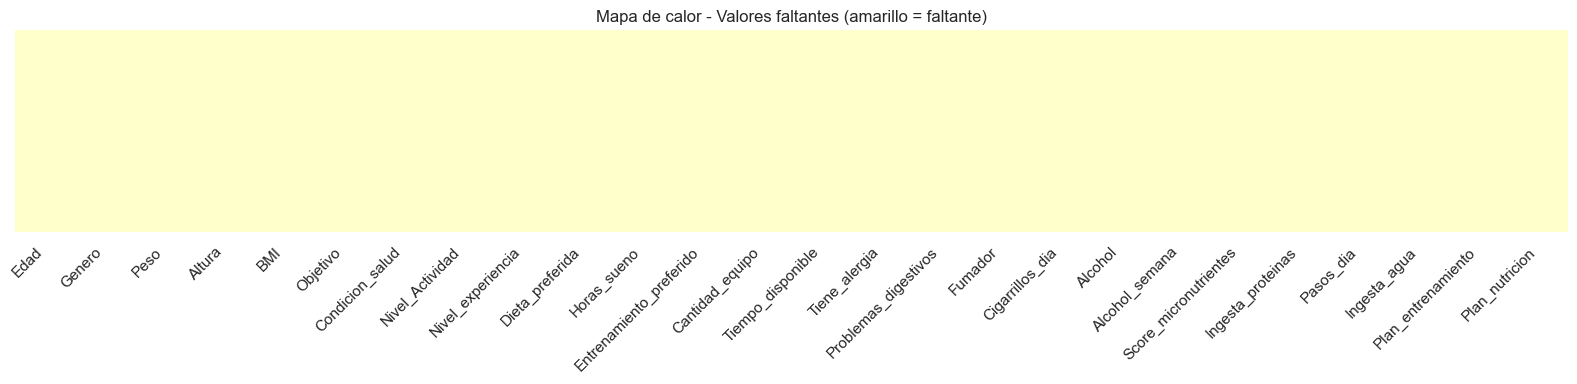

In [6]:
# Mapa de calor de valores faltantes (todas las columnas)
plt.figure(figsize=(16, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='YlOrRd', yticklabels=False)
plt.title('Mapa de calor - Valores faltantes (amarillo = faltante)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Análisis:** Se observa que la columna `Peso` presenta algunos valores faltantes. Dado que el BMI ya está calculado en el dataset y puede usarse como indicador de composición corporal, los valores faltantes en `Peso` podrían imputarse con la mediana o derivarse del BMI y la Altura. En el Paso 2 se definirá la estrategia de imputación más adecuada.

### 4. Detección de registros duplicados

In [7]:
n_duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas: {n_duplicados}")

if n_duplicados > 0:
    print("\nFilas duplicadas:")
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()))
else:
    print("No se encontraron filas completamente duplicadas en el dataset.")

Número de filas duplicadas: 0
No se encontraron filas completamente duplicadas en el dataset.


### 5. Análisis univariado - Variables numéricas

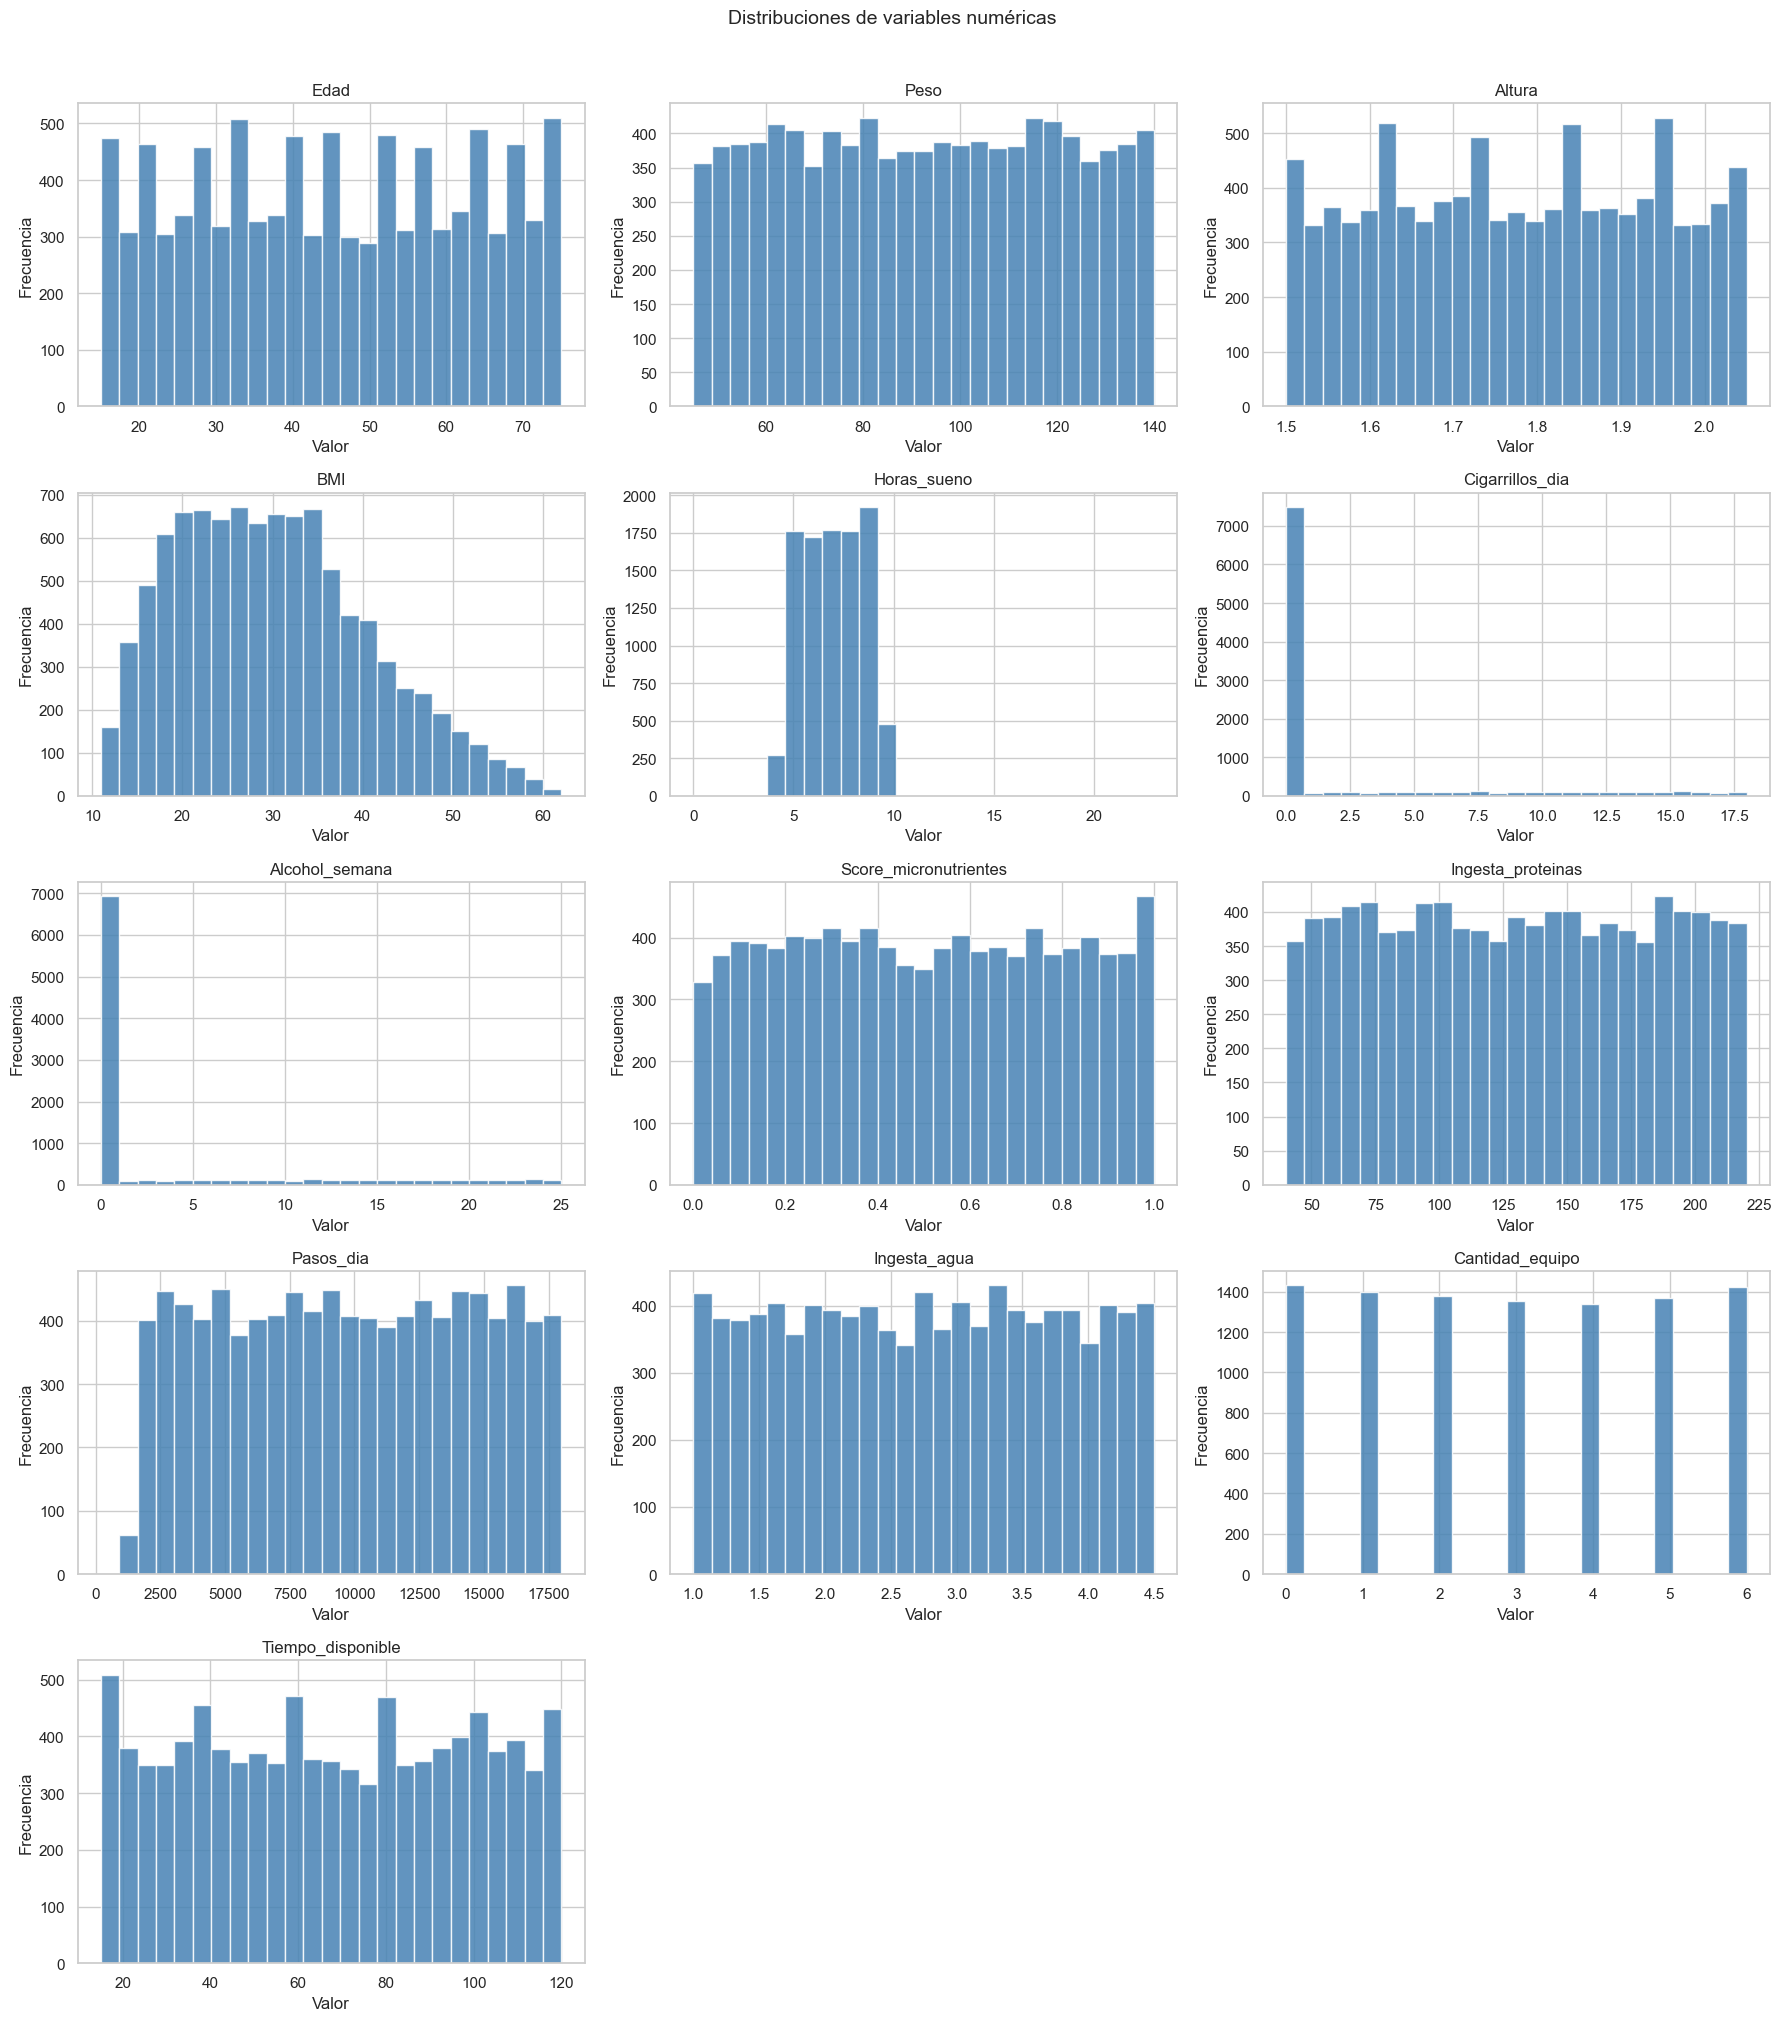

In [8]:
# Variables numéricas a analizar (excluir binarias y targets)
vars_num = ['Edad', 'Peso', 'Altura', 'BMI', 'Horas_sueno',
            'Cigarrillos_dia', 'Alcohol_semana', 'Score_micronutrientes',
            'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua',
            'Cantidad_equipo', 'Tiempo_disponible']

# Histogramas
n_cols = 3
n_rows = (len(vars_num) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(vars_num):
    axes[i].hist(df[col].dropna(), bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

for j in range(len(vars_num), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribuciones de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

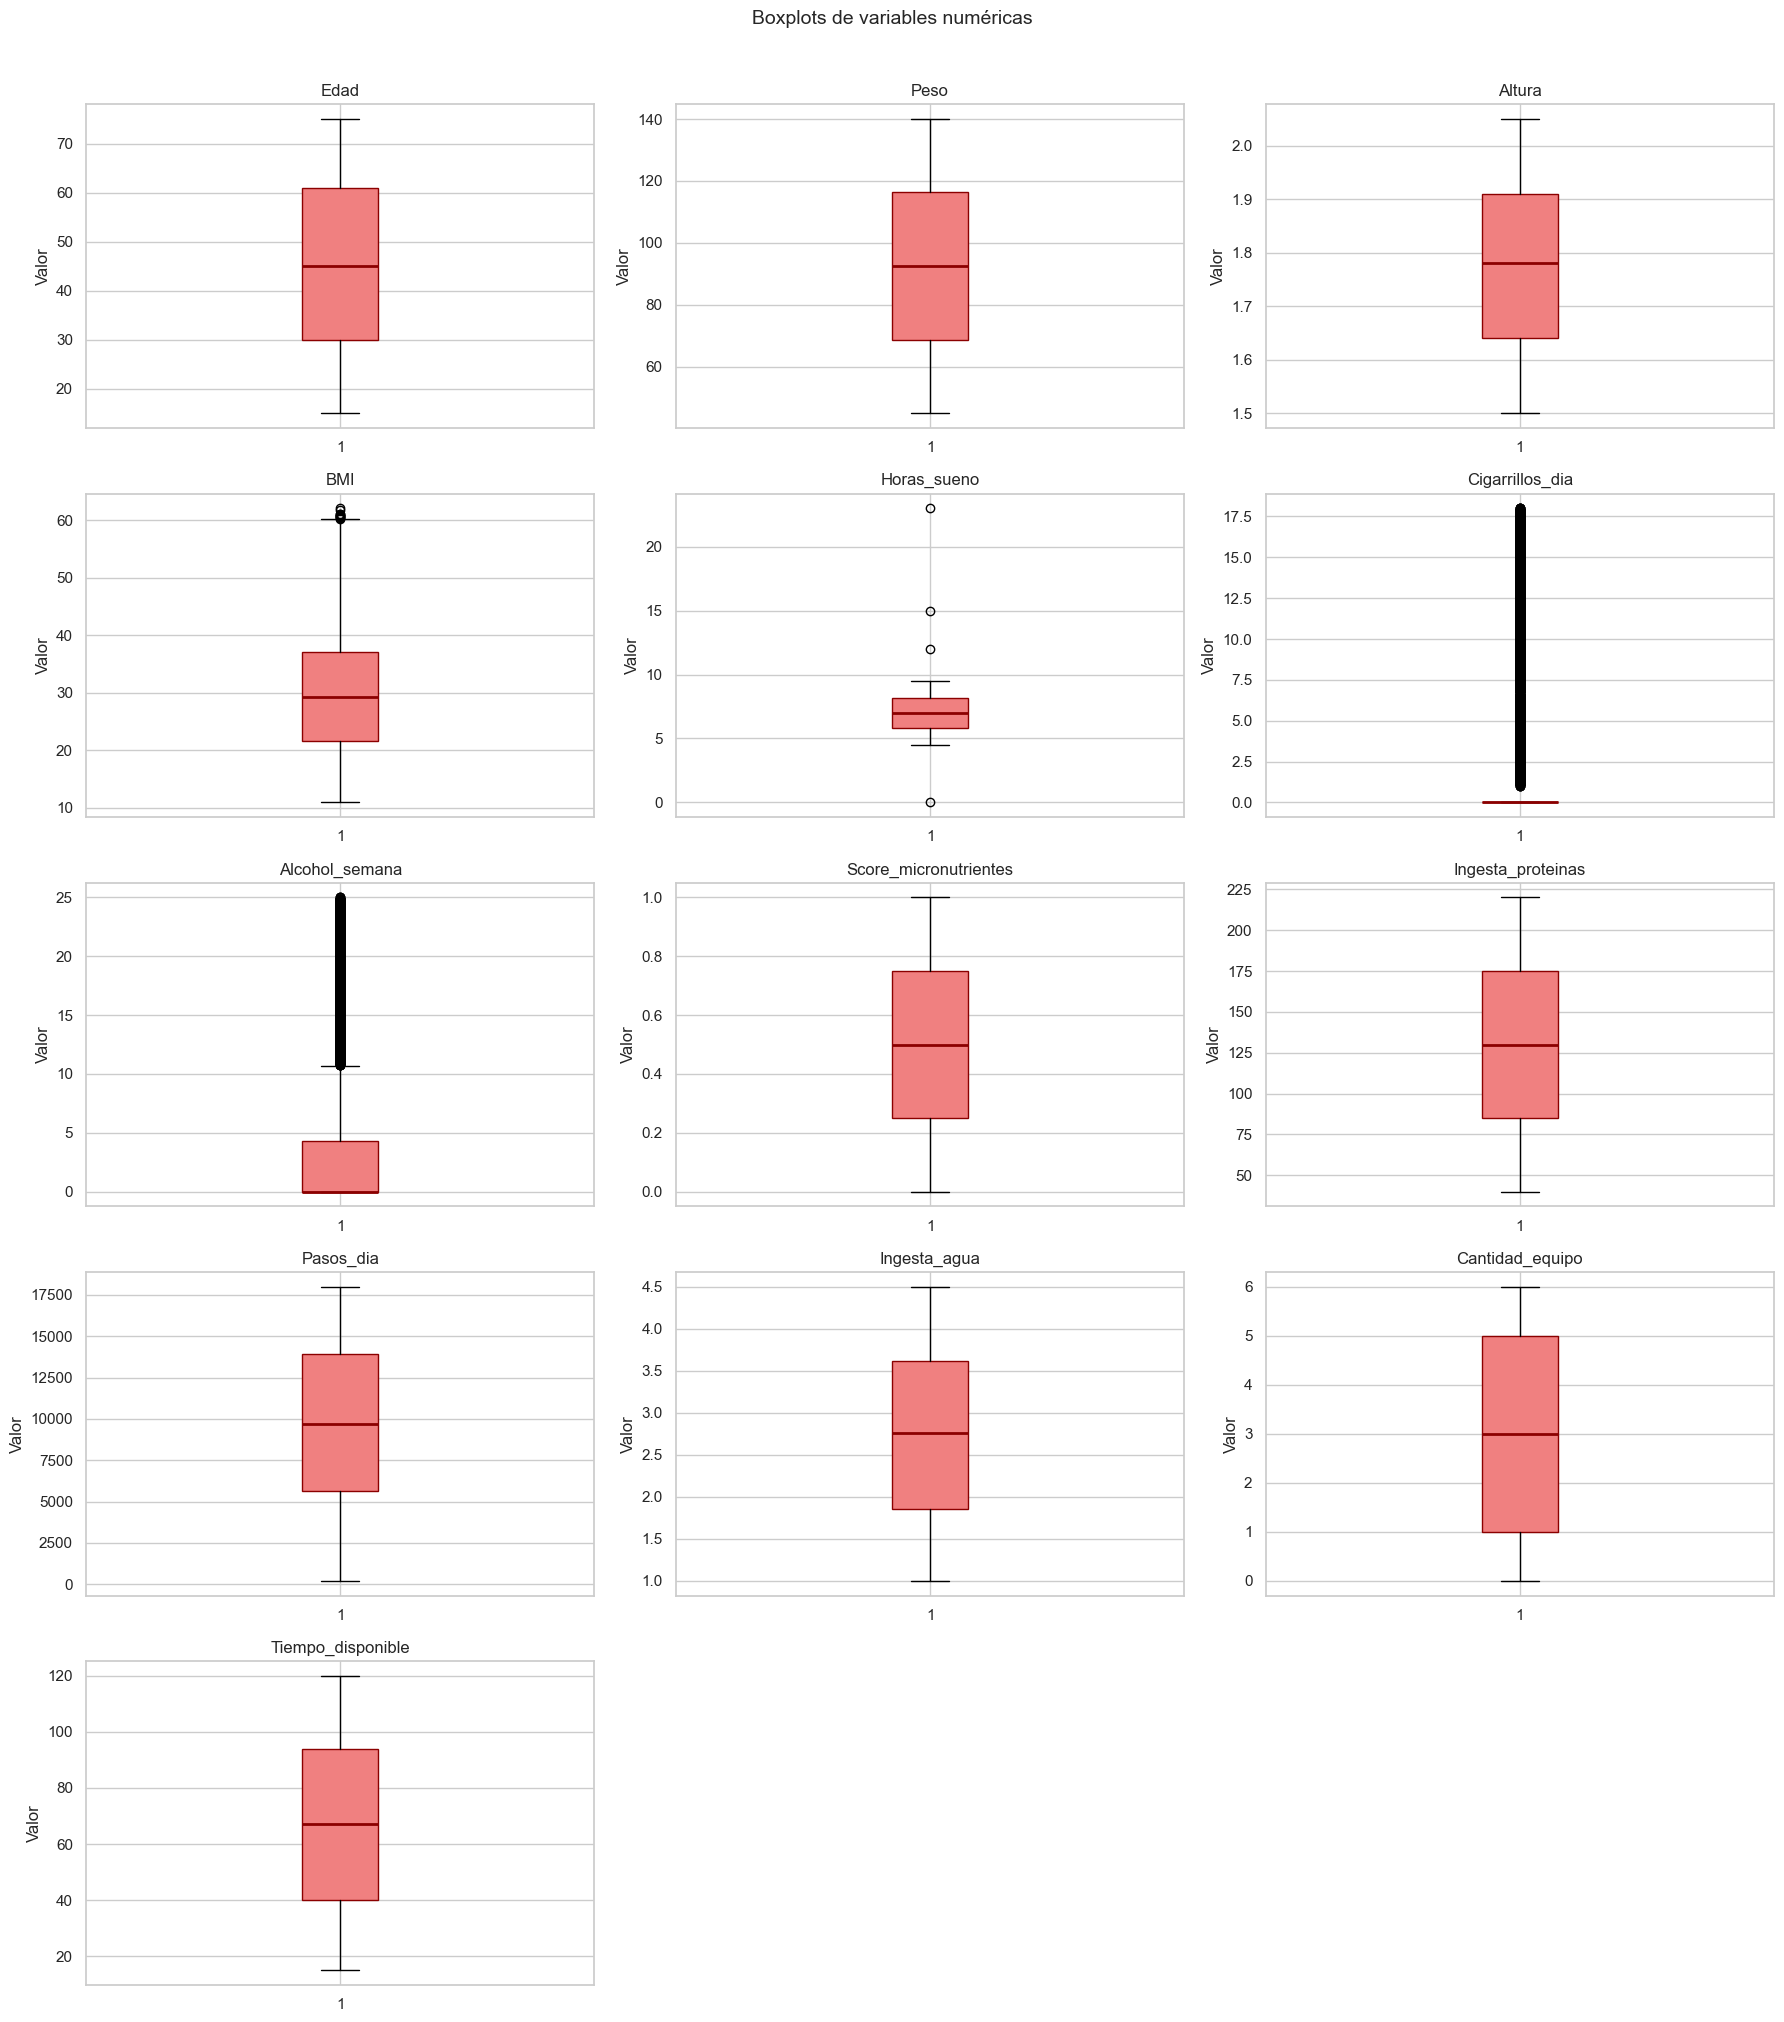


Asimetría (skewness) por variable numérica:
Cigarrillos_dia          2.037
Alcohol_semana           1.688
BMI                      0.460
Horas_sueno              0.148
Score_micronutrientes    0.013
Cantidad_equipo          0.012
Ingesta_proteinas        0.006
Edad                     0.004
Tiempo_disponible        0.002
Altura                  -0.001
Peso                    -0.003
Ingesta_agua            -0.003
Pasos_dia               -0.010
dtype: float64


In [9]:
# Boxplots para detectar dispersión y posibles outliers
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(vars_num):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightcoral', color='darkred'),
                    medianprops=dict(color='darkred', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_ylabel('Valor')

for j in range(len(vars_num), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Boxplots de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Asimetría (skewness)
print("\nAsimetría (skewness) por variable numérica:")
skew = df[vars_num].skew().round(3).sort_values(ascending=False)
print(skew)

### 6. Análisis univariado - Variables categóricas

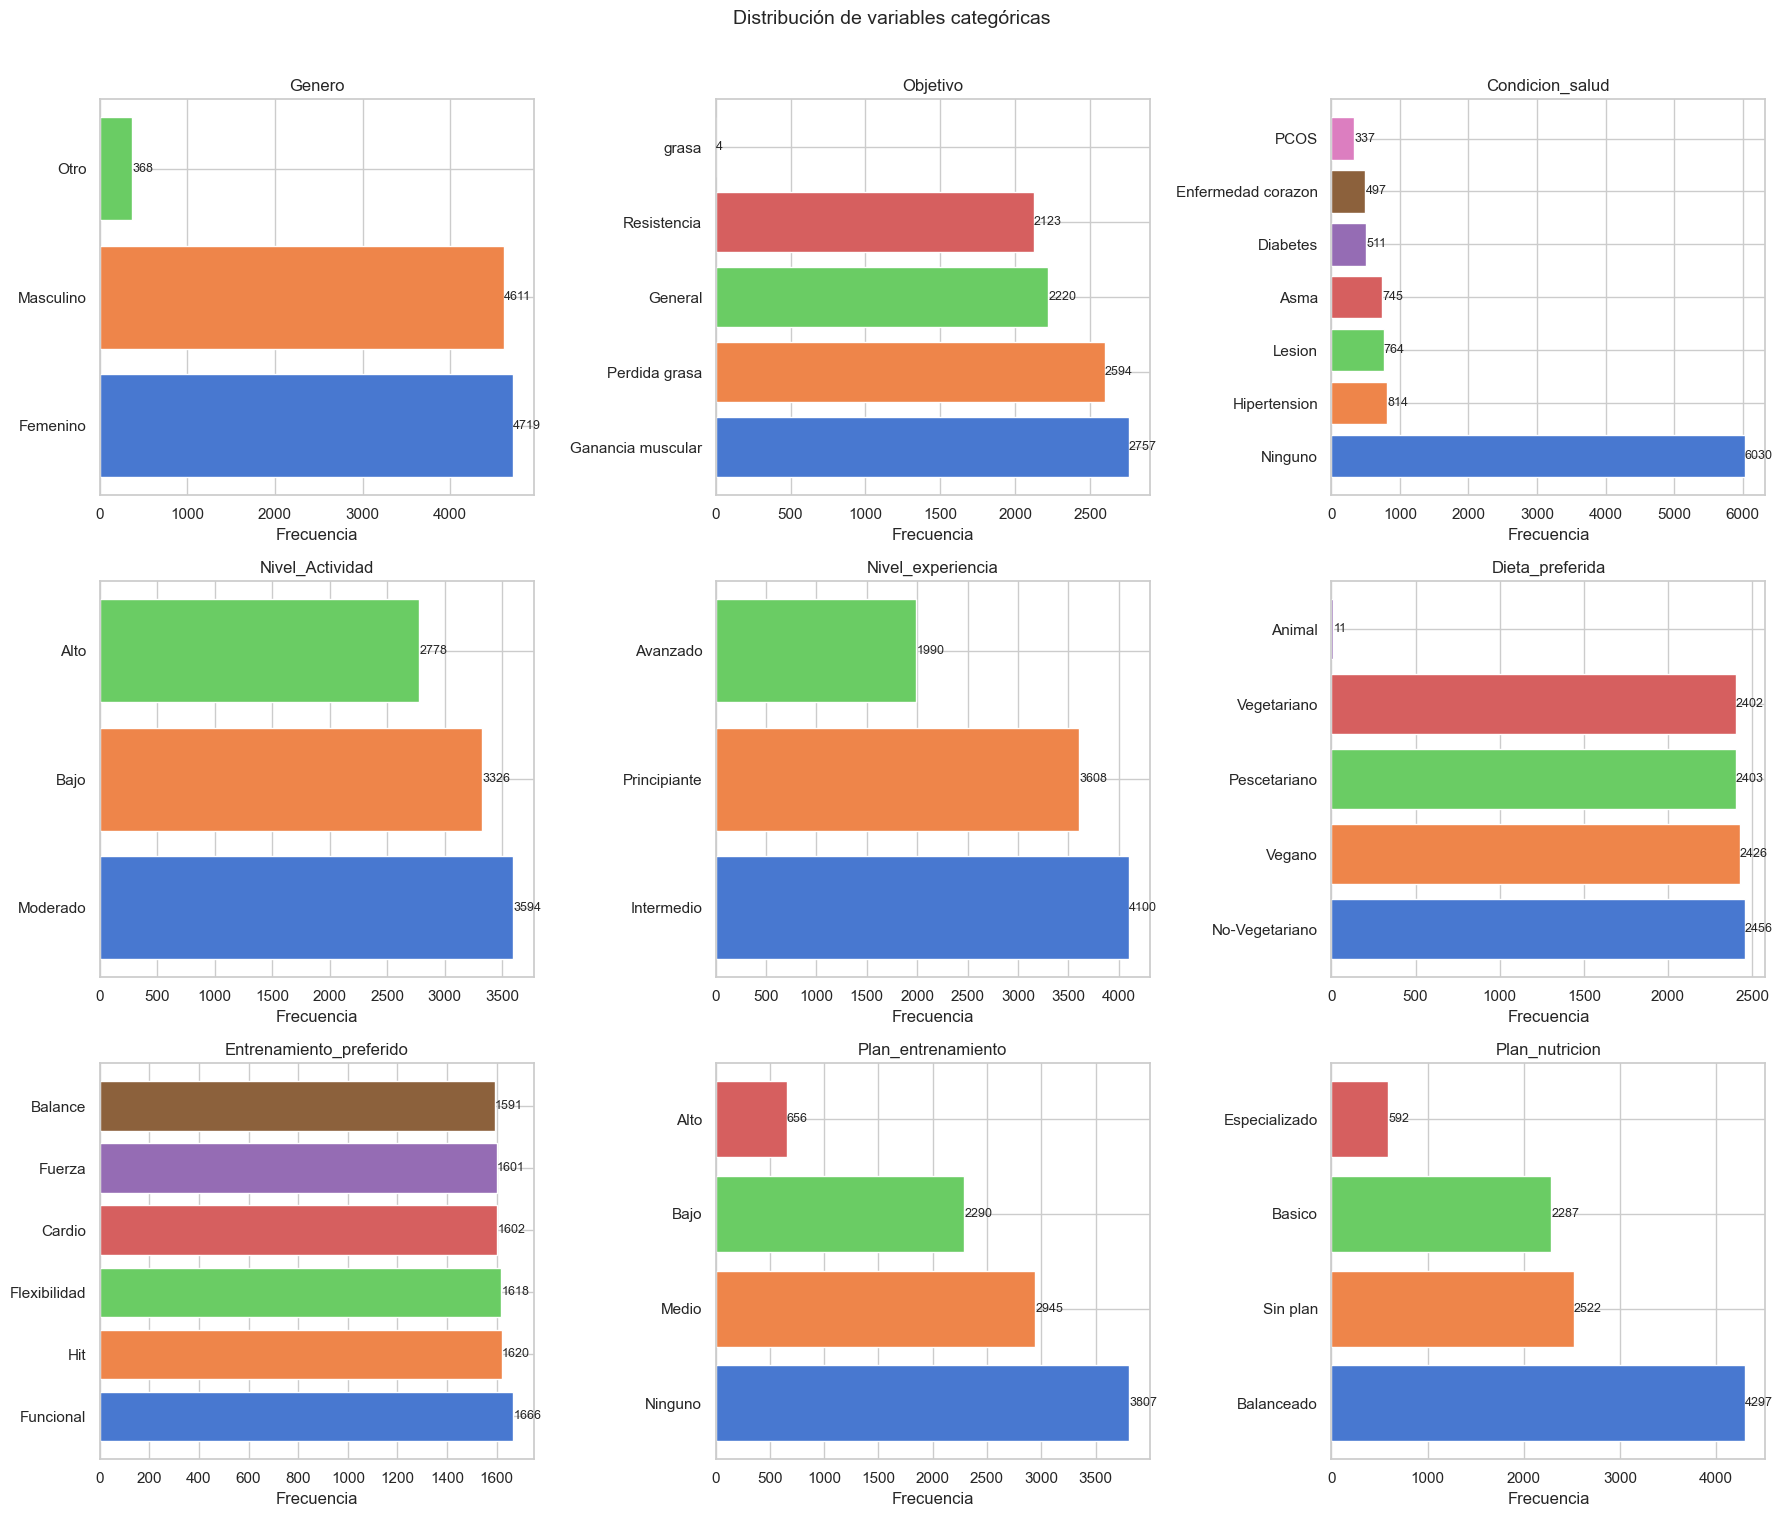

In [10]:
vars_cat = ['Genero', 'Objetivo', 'Condicion_salud', 'Nivel_Actividad',
            'Nivel_experiencia', 'Dieta_preferida', 'Entrenamiento_preferido',
            'Plan_entrenamiento', 'Plan_nutricion']

n_cols_c = 3
n_rows_c = (len(vars_cat) + n_cols_c - 1) // n_cols_c
fig, axes = plt.subplots(n_rows_c, n_cols_c, figsize=(18, n_rows_c * 5))
axes = axes.flatten()

for i, col in enumerate(vars_cat):
    counts = df[col].value_counts()
    axes[i].barh(counts.index.astype(str), counts.values,
                 color=sns.color_palette('muted', len(counts)))
    axes[i].set_title(col)
    axes[i].set_xlabel('Frecuencia')
    for j, v in enumerate(counts.values):
        axes[i].text(v + 0.5, j, str(v), va='center', fontsize=9)

for j in range(len(vars_cat), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribución de variables categóricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# Tabla de frecuencias para variables categóricas adicionales (binarias)
vars_bin = ['Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Alcohol']

print("Frecuencias de variables binarias:\n")
for col in vars_bin:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

Frecuencias de variables binarias:

--- Tiene_alergia ---
Tiene_alergia
0    7743
1    1955
Name: count, dtype: int64

--- Problemas_digestivos ---
Problemas_digestivos
0    8206
1    1492
Name: count, dtype: int64

--- Fumador ---
Fumador
0    7493
1    2205
Name: count, dtype: int64

--- Alcohol ---
Alcohol
0    6931
1    2767
Name: count, dtype: int64



### 7. Análisis bivariado: Variables vs. Variables objetivo

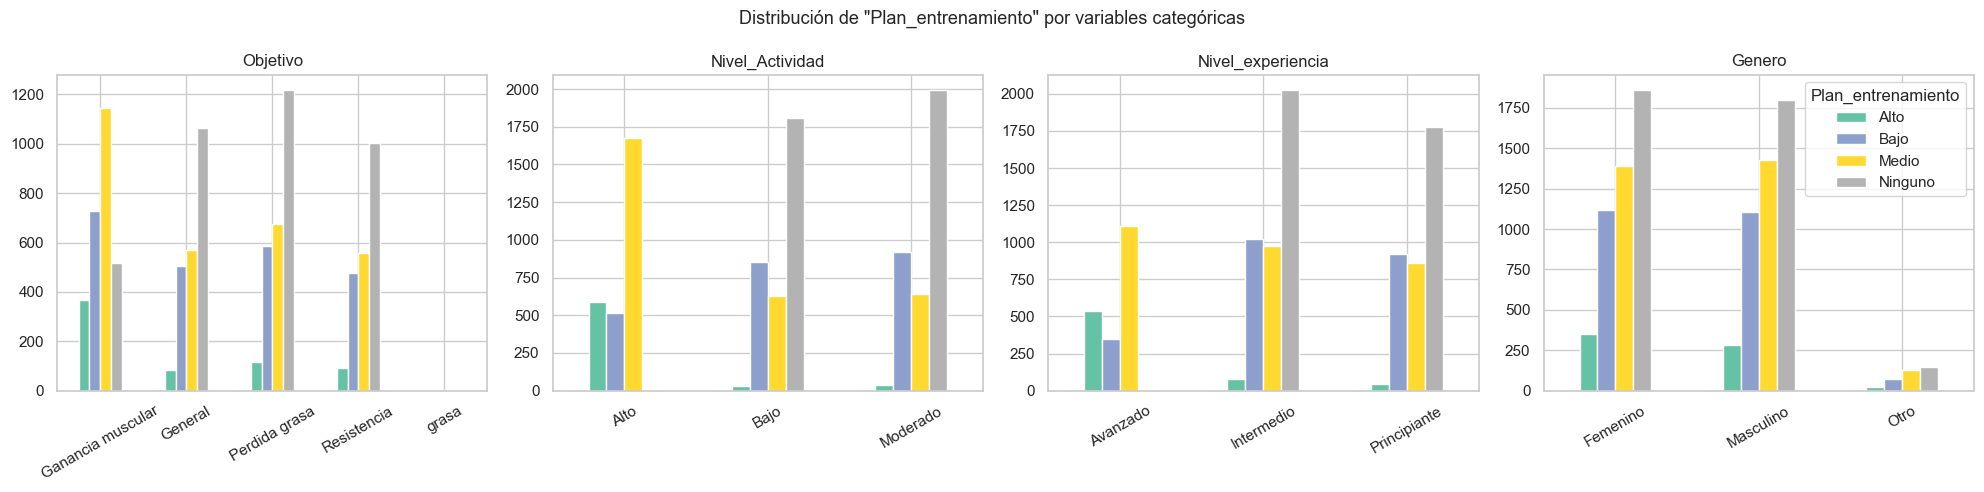

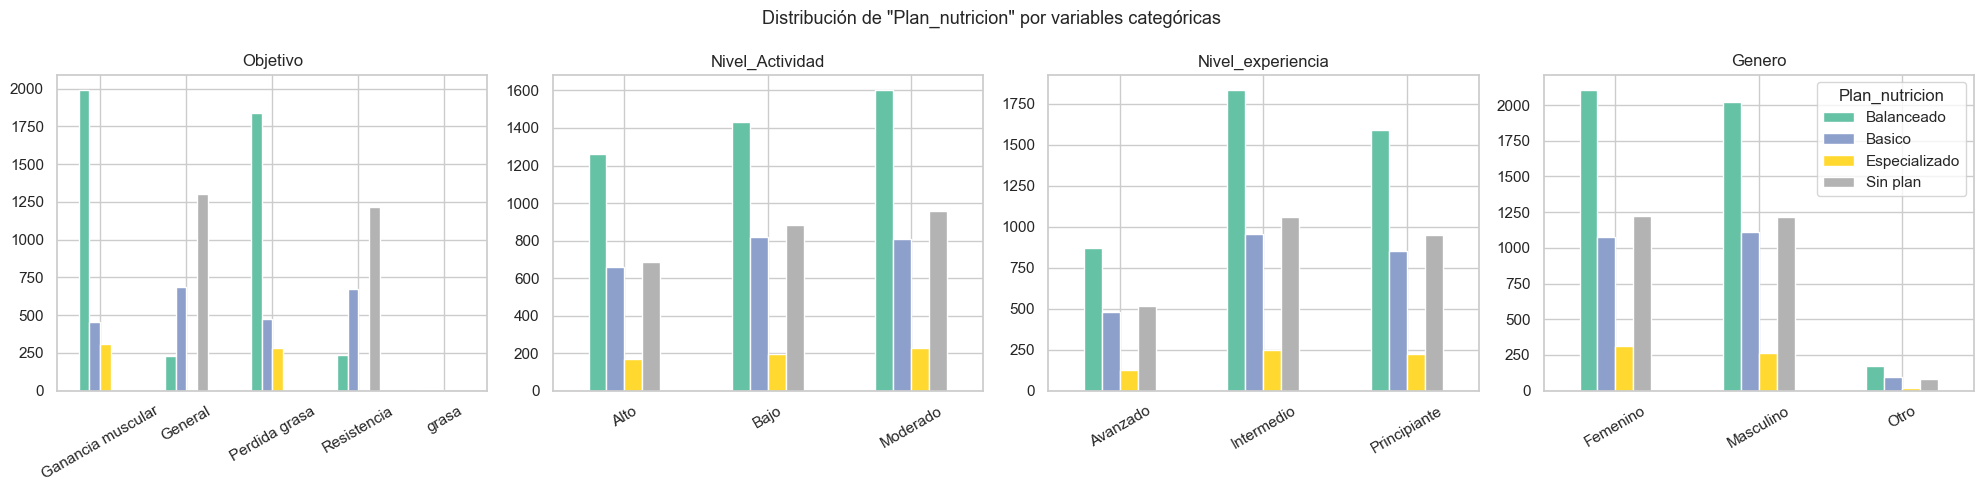

In [12]:
targets = ['Plan_entrenamiento', 'Plan_nutricion']
features_cat_biv = ['Objetivo', 'Nivel_Actividad', 'Nivel_experiencia', 'Genero']

for target in targets:
    fig, axes = plt.subplots(1, len(features_cat_biv), figsize=(20, 5))
    fig.suptitle(f'Distribución de "{target}" por variables categóricas', fontsize=13)
    for i, feat in enumerate(features_cat_biv):
        ct = pd.crosstab(df[feat], df[target])
        ct.plot(kind='bar', ax=axes[i], stacked=False, colormap='Set2', legend=(i == len(features_cat_biv)-1))
        axes[i].set_title(feat)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

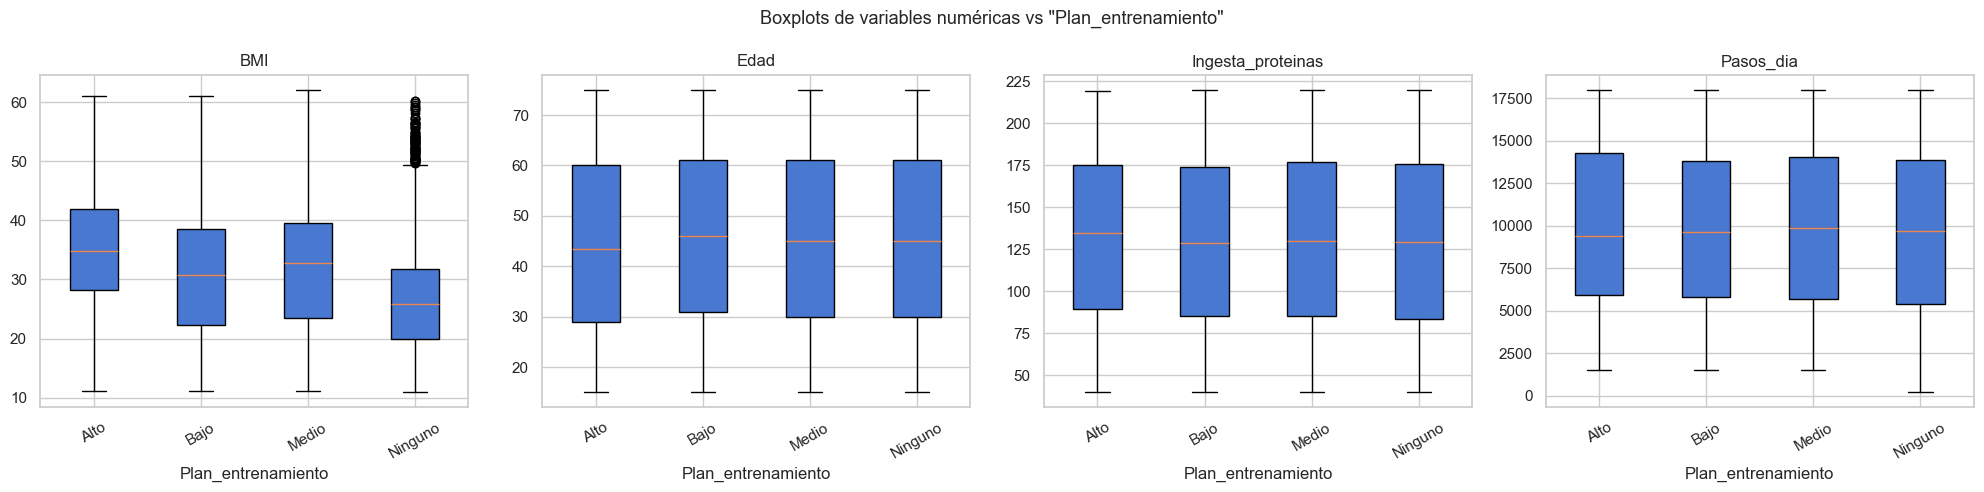

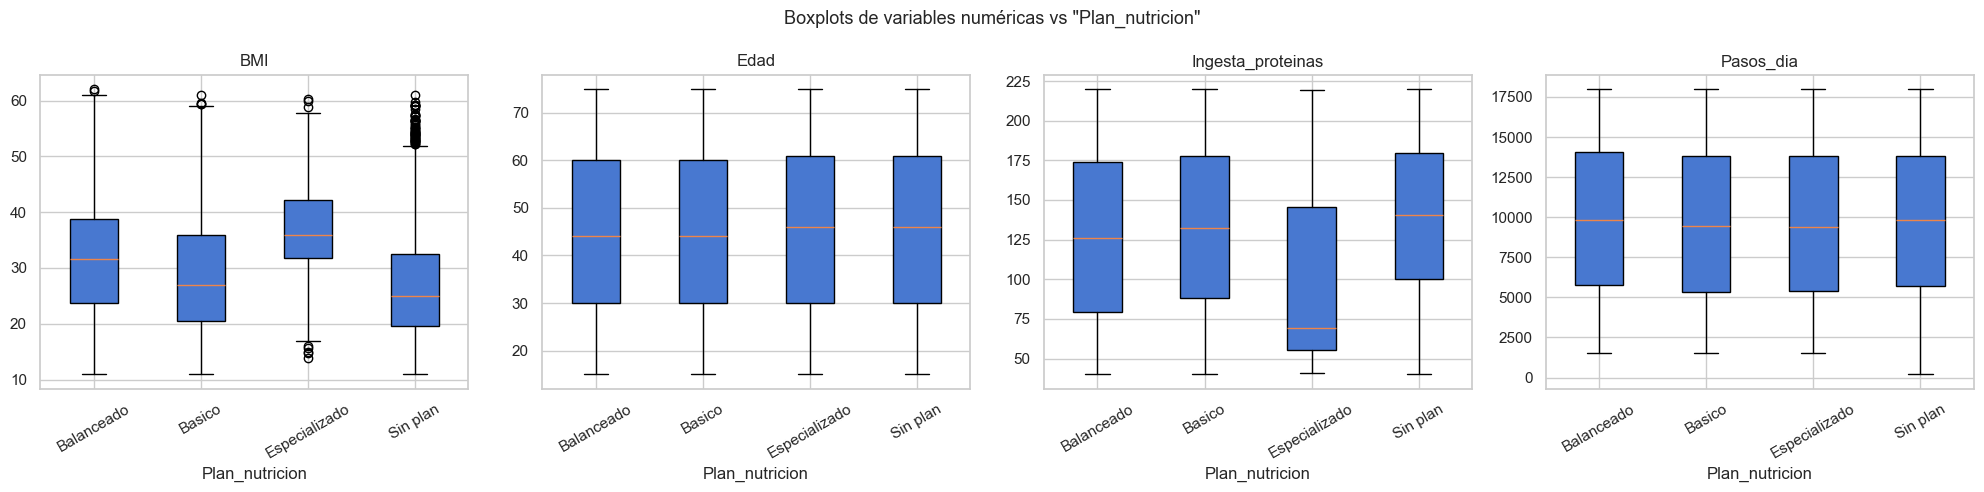

In [13]:
features_num_biv = ['BMI', 'Edad', 'Ingesta_proteinas', 'Pasos_dia']

for target in targets:
    fig, axes = plt.subplots(1, len(features_num_biv), figsize=(20, 5))
    fig.suptitle(f'Boxplots de variables numéricas vs "{target}"', fontsize=13)
    for i, feat in enumerate(features_num_biv):
        order = sorted(df[target].dropna().unique())
        data_groups = [df[df[target] == cls][feat].dropna() for cls in order]
        axes[i].boxplot(data_groups, labels=order, patch_artist=True)
        axes[i].set_title(feat)
        axes[i].set_xlabel(target)
        axes[i].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()

### 8. Detección de valores atípicos (Outliers)

Se utiliza el método IQR para identificar outliers en variables numéricas:

$$IQR = Q_3 - Q_1$$
$$\text{Límite inferior} = Q_1 - 1.5 \times IQR \qquad \text{Límite superior} = Q_3 + 1.5 \times IQR$$

In [14]:
vars_outlier = ['Peso', 'BMI', 'Cigarrillos_dia', 'Alcohol_semana',
                'Ingesta_proteinas', 'Pasos_dia', 'Tiempo_disponible', 'Ingesta_agua']

outlier_summary = []
for col in vars_outlier:
    serie = df[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((serie < lower) | (serie > upper)).sum()
    pct = round(n_outliers / len(serie) * 100, 2)
    outlier_summary.append({'Variable': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
                             'IQR': round(IQR, 2), 'Límite inferior': round(lower, 2),
                             'Límite superior': round(upper, 2),
                             'N° outliers': n_outliers, '% outliers': pct})

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,N° outliers,% outliers
0,Peso,68.80,116.50,47.70,-2.75,188.05,0,0.00
1,BMI,21.62,37.06,15.44,-1.54,60.22,12,0.12
2,Cigarrillos_dia,0.00,0.00,0.00,0.00,0.00,2205,22.74
3,Alcohol_semana,0.00,4.30,4.30,-6.45,10.75,1695,17.48
4,Ingesta_proteinas,85.00,175.20,90.20,-50.30,310.50,0,0.00
5,Pasos_dia,5608.25,13953.00,8344.75,-6908.88,26470.12,0,0.00
6,Tiempo_disponible,40.00,94.00,54.00,-41.00,175.00,0,0.00
7,Ingesta_agua,1.86,3.62,1.76,-0.78,6.26,0,0.00


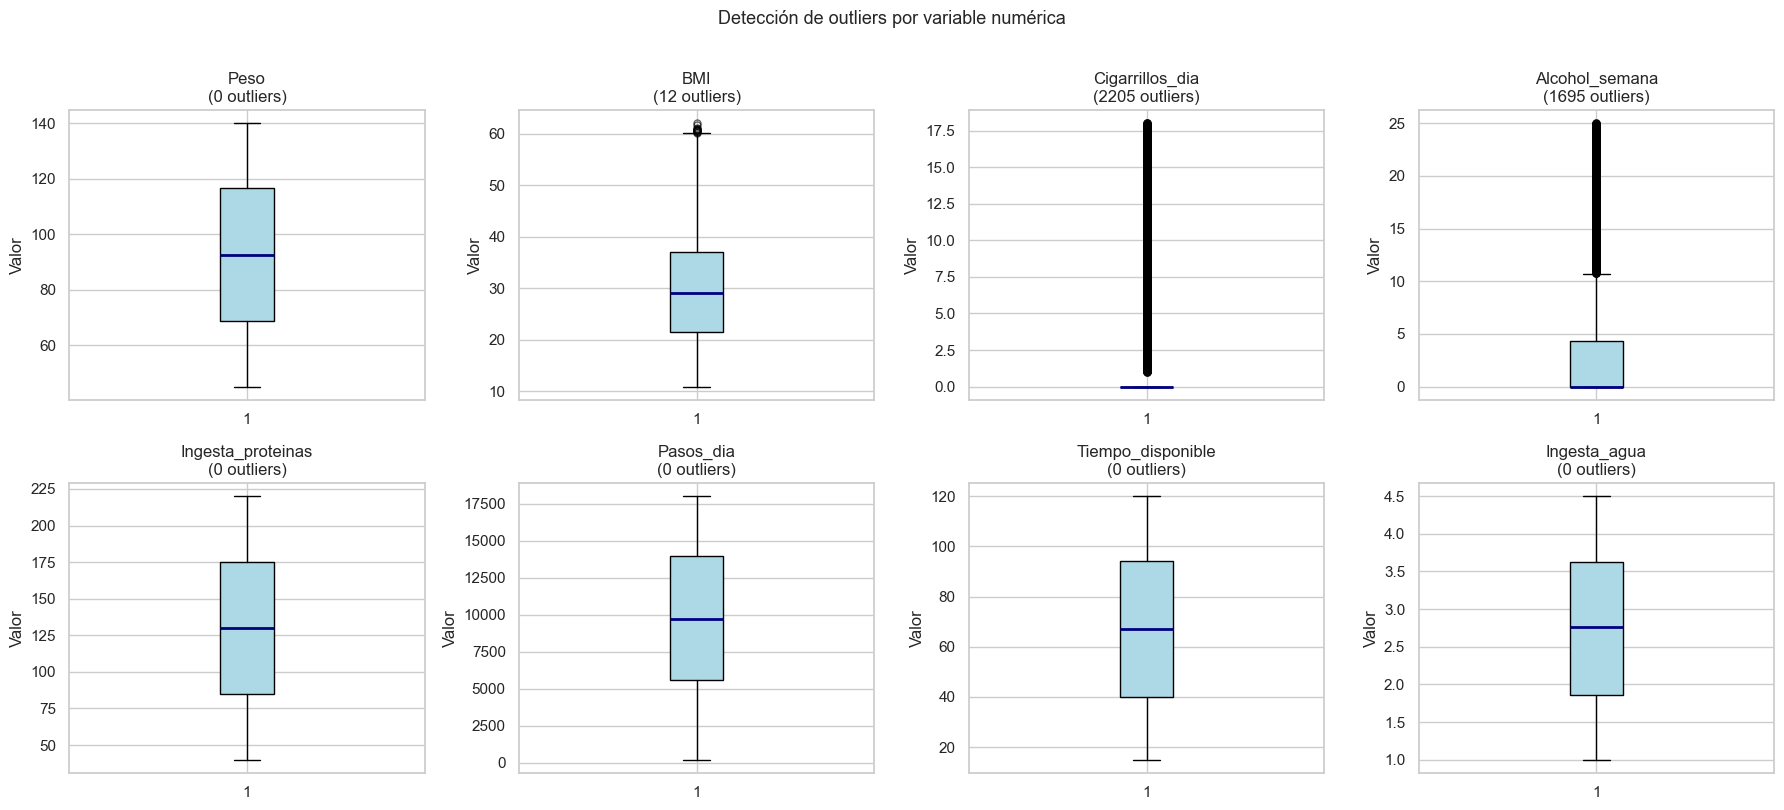

In [15]:
# Visualización de outliers con boxplots destacados
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(vars_outlier):
    serie = df[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = serie[(serie < lower) | (serie > upper)]
    inliers = serie[(serie >= lower) & (serie <= upper)]
    
    axes[i].boxplot(serie, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='navy', linewidth=2),
                    flierprops=dict(marker='o', color='red', markersize=5, alpha=0.6))
    axes[i].set_title(f'{col}\n({len(outliers)} outliers)')
    axes[i].set_ylabel('Valor')

fig.suptitle('Detección de outliers por variable numérica', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Análisis de outliers:** Las variables como `Cigarrillos_dia` y `Alcohol_semana` presentan outliers que reflejan hábitos extremos reales (fumadores o bebedores intensos). El `BMI` presenta algunos valores muy altos, lo que puede corresponder a casos de obesidad severa, pero son valores posibles en el contexto de un gimnasio. Se deben tratar con cuidado y no eliminar directamente sin investigar el contexto.

### 9. Análisis de distribución de clases (variables objetivo)

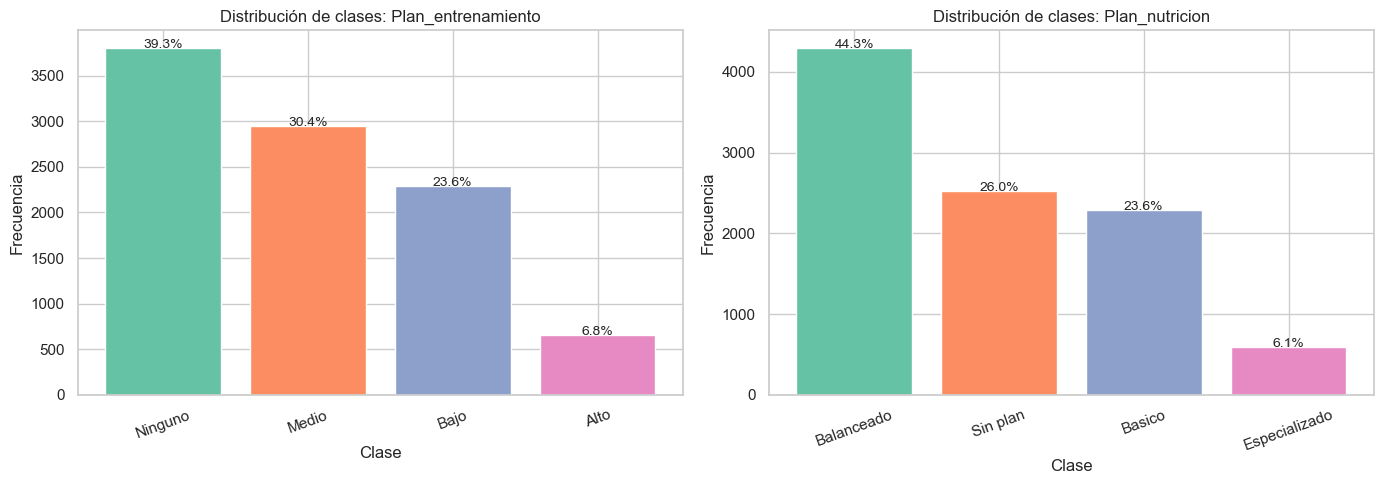


Proporción de clases (%):

--- Plan_entrenamiento ---
Plan_entrenamiento
Ninguno    39.26
Medio      30.37
Bajo       23.61
Alto        6.76

--- Plan_nutricion ---
Plan_nutricion
Balanceado       44.31
Sin plan         26.01
Basico           23.58
Especializado     6.10



In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, target in enumerate(targets):
    counts = df[target].value_counts()
    pcts = (counts / counts.sum() * 100).round(1)
    bars = axes[i].bar(counts.index.astype(str), counts.values,
                       color=sns.color_palette('Set2', len(counts)))
    axes[i].set_title(f'Distribución de clases: {target}')
    axes[i].set_xlabel('Clase')
    axes[i].set_ylabel('Frecuencia')
    for bar, pct in zip(bars, pcts):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 1, f'{pct}%', ha='center', fontsize=10)
    axes[i].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print("\nProporción de clases (%):\n")
for target in targets:
    print(f"--- {target} ---")
    print((df[target].value_counts(normalize=True) * 100).round(2).to_string())
    print()

### 10. Resumen de problemas de calidad de datos

A continuación se consolidan todos los hallazgos encontrados durante la exploración.

In [17]:
resumen = pd.DataFrame({
    'Problema identificado': [
        'Valores faltantes en Peso',
        'Nombre de columna incorrecto (Gnereo)',
        'Problemas de codificación (Horas_sueño, Plan_nutrición)',
        'Valores atípicos en BMI, Cigarrillos_dia, Alcohol_semana',
        'Posible redundancia: Peso + Altura y BMI',
        'Variables con ceros que dependen de otras (Cigarrillos_dia cuando Fumador=0)',
        'Desbalance de clases en variables objetivo',
        'Categoría poco frecuente en Genero (Otro)',
        'Categoría Animal en Dieta_preferida poco documentada'
    ],
    'Tipo de problema': [
        'Valores faltantes',
        'Error tipográfico en nombre de columna',
        'Codificación de caracteres especiales',
        'Outliers',
        'Posible redundancia',
        'Inconsistencia lógica',
        'Desbalance de clases',
        'Clase minoritaria',
        'Ambigüedad semántica'
    ],
    'Acción propuesta para Paso 2': [
        'Imputar con la mediana de Peso o derivar de BMI y Altura',
        'Renombrar columna a "Genero"',
        'Leer con encoding latin-1 y renombrar columnas al cargar',
        'Conservar outliers válidos; aplicar escalado robusto en el pipeline',
        'Evaluar correlación y decidir si eliminar Peso o Altura del modelo',
        'Verificar consistencia: si Fumador=0 entonces Cigarrillos_dia=0',
        'Evaluar class_weight="balanced" o estratificar el split',
        'Mantener la categoría; el modelo la tratará como una clase más',
        'Consultar el diccionario de datos para clarificar su significado'
    ]
})

display(resumen)

,Problema identificado,Tipo de problema,Acción propuesta para Paso 2
0,Valores faltantes en Peso,Valores faltantes,Imputar con la mediana de Peso o derivar de BM...
1,Nombre de columna incorrecto (Gnereo),Error tipográfico en nombre de columna,"Renombrar columna a ""Genero"""
2,"Problemas de codificación (Horas_sueño, Plan_n...",Codificación de caracteres especiales,Leer con encoding latin-1 y renombrar columnas...
3,"Valores atípicos en BMI, Cigarrillos_dia, Alco...",Outliers,Conservar outliers válidos; aplicar escalado r...
4,Posible redundancia: Peso + Altura y BMI,Posible redundancia,Evaluar correlación y decidir si eliminar Peso...
5,Variables con ceros que dependen de otras (Cig...,Inconsistencia lógica,Verificar consistencia: si Fumador=0 entonces ...
6,Desbalance de clases en variables objetivo,Desbalance de clases,"Evaluar class_weight=""balanced"" o estratificar..."
7,Categoría poco frecuente en Genero (Otro),Clase minoritaria,Mantener la categoría; el modelo la tratará co...
8,Categoría Animal en Dieta_preferida poco docum...,Ambigüedad semántica,Consultar el diccionario de datos para clarifi...


### Conclusiones del Paso 1

1. **Estructura del dataset:** El conjunto de datos cuenta con 26 columnas (24 variables de entrada + 2 variables objetivo: `Plan_entrenamiento` y `Plan_nutricion`). Incluye variables numéricas continuas (Peso, BMI, Ingesta_proteinas, etc.), variables numéricas discretas (Cantidad_equipo, Pasos_dia) y variables categóricas (Objetivo, Genero, Dieta_preferida, etc.).

2. **Valores faltantes:** Se identificaron valores faltantes principalmente en la columna `Peso`. El porcentaje es bajo y puede manejarse con imputación por mediana. No se detectaron valores faltantes en las variables objetivo del conjunto de entrenamiento.

3. **Duplicados:** No se encontraron filas completamente duplicadas en el dataset.

4. **Outliers:** Variables como `BMI`, `Cigarrillos_dia` y `Alcohol_semana` presentan valores atípicos que son plausibles en el contexto real del gimnasio. No corresponden a errores de captura sino a perfiles extremos de usuarios.

5. **Problemas de calidad en nombres de columnas:** La columna `Gnereo` es un error tipográfico que debe corregirse a `Genero`. Las columnas con tildes (`Horas_sueño`, `Plan_nutrición`) presentan problemas de codificación que se resuelven usando `encoding='latin-1'` al cargar.

6. **Distribución de clases:** Ambas variables objetivo presentan cierto grado de desbalance de clases. En el Paso 2 y en el modelado se considerará el uso de `class_weight='balanced'` y validación cruzada estratificada.

7. **Posible redundancia:** Las columnas `Peso`, `Altura` y `BMI` están matemáticamente relacionadas (BMI = Peso / Altura²), lo que puede generar multicolinealidad en modelos lineales. En el paso de preparación se evaluará si conviene eliminar alguna de estas variables.

8. **Inconsistencia lógica:** La columna `Cigarrillos_dia` debería ser 0 cuando `Fumador=0`, y `Alcohol_semana` debería ser 0 cuando `Alcohol=0`. Se verificará esta consistencia en el Paso 2.